# Bank Marketing Campaign: Customer Response Analysis & Call Targeting

## Business Problem
A Portuguese retail bank phoned its customers to sell a **term deposit**. Only about 1 in 9 customers said yes, so most calls were wasted.

**Goal:**
1. Find which customer groups respond best to the campaign.
2. Build a simple model that ranks customers **before they are called**, so the bank can call the most likely subscribers first.

**Dataset:** UCI Bank Marketing (`bank-full.csv`), May 2008 – November 2010, 45,211 customers, 17 columns.

**Project flow (end to end):**

| Step | Tool | Output |
|---|---|---|
| 1. Clean data, create variables, explore, test hypotheses | Python | Response tables, charts, chi-square tests |
| 2. Score customers and build targeting segments | Python (Logistic Regression) | Response score + 4 segments, lift table |
| 3. Segment queries on the scored data | SQL (PostgreSQL) | `bank_marketing_campaign.sql` |
| 4. Summary workbook and dashboard | Excel + Power BI | KPIs, segment tables, call plan |

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, confusion_matrix

## 2. Load the Data and Check Quality
The original UCI file uses a semicolon (`;`) as the separator.

In [3]:
bank = pd.read_csv("bank-full.csv", sep=";")

print("Rows and columns:", bank.shape)
print("Missing values:", bank.isnull().sum().sum())
print("Duplicate rows:", bank.duplicated().sum())
bank.head()

Rows and columns: (45211, 17)
Missing values: 0
Duplicate rows: 0


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


### Check for "unknown" values
The dataset has no blank cells, but some columns use the word `unknown` instead.

In [4]:
for column in ["job", "education", "contact", "poutcome"]:
    unknown_share = (bank[column] == "unknown").mean() * 100
    print(column, ":", round(unknown_share, 1), "% unknown")

job : 0.6 % unknown
education : 4.1 % unknown
contact : 28.8 % unknown
poutcome : 81.7 % unknown


**Decision:** `unknown` is kept as its own category instead of being filled in.
- `poutcome = unknown` means the customer was **never in a previous campaign**. That is real information, not missing data.
- For `job`, `education` and `contact`, guessing a value would add made-up data.

### Check the numeric columns

In [5]:
bank[["age", "balance", "campaign", "previous"]].describe().round(1)

,age,balance,campaign,previous
count,45211.0,45211.0,45211.0,45211.0
mean,40.9,1362.3,2.8,0.6
std,10.6,3044.8,3.1,2.3
min,18.0,-8019.0,1.0,0.0
25%,33.0,72.0,1.0,0.0
50%,39.0,448.0,2.0,0.0
75%,48.0,1428.0,3.0,0.0
max,95.0,102127.0,63.0,275.0


**Notes:**
- `balance` has negative values (overdrawn accounts) and very large values. These are real customers, so they are kept.
- `campaign` (calls in this campaign) goes up to 63 for a few customers. These are grouped into a "6+ calls" band below instead of being removed.

### Column meanings
- `y`: target. `yes` = subscribed to the term deposit.
- `poutcome`: result of the **previous** campaign.
- `campaign`: number of calls made to the customer in **this** campaign.
- `previous`: number of calls made **before** this campaign.
- `duration`: length of the last call. Known only **after** the call ends, so it is **not used in the model**.

## 3. Create Analysis Variables

In [6]:
# Unique ID for SQL, Excel and Power BI
bank.insert(0, "customer_id", range(1, len(bank) + 1))

# Target as 1/0, so the average of this column is the response rate
bank["subscribed"] = (bank["y"] == "yes").astype(int)

# Age groups
bank["age_group"] = pd.cut(
    bank["age"],
    bins=[0, 30, 40, 50, 60, 200],
    labels=["<=30", "31-40", "41-50", "51-60", "60+"]
)

# Number-of-calls groups
bank["contact_band"] = pd.cut(
    bank["campaign"],
    bins=[0, 1, 3, 5, 100],
    labels=["1 Contact", "2-3 Contacts", "4-5 Contacts", "6+ Contacts"]
)

# Balance in thousands of euros (keeps the number small for the model)
bank["balance_000"] = bank["balance"] / 1000

bank[["customer_id", "age", "age_group", "campaign", "contact_band", "subscribed"]].head()

,customer_id,age,age_group,campaign,contact_band,subscribed
0,1,58,51-60,1,1 Contact,0
1,2,44,41-50,1,1 Contact,0
2,3,33,31-40,1,1 Contact,0
3,4,47,41-50,1,1 Contact,0
4,5,33,31-40,1,1 Contact,0


## 4. Overall Campaign KPIs

In [7]:
total_customers = len(bank)
total_subscribers = bank["subscribed"].sum()
overall_rate = bank["subscribed"].mean() * 100

print("Total customers:", total_customers)
print("Total subscribers:", total_subscribers)
print("Overall response rate:", round(overall_rate, 2), "%")
print("Average calls per customer:", round(bank["campaign"].mean(), 2))
print("Calls needed per subscriber if customers are called at random:", round(100 / overall_rate, 1))

Total customers: 45211
Total subscribers: 5289
Overall response rate: 11.7 %
Average calls per customer: 2.76
Calls needed per subscriber if customers are called at random: 8.5


## 5. Exploratory Analysis: Response Rate by Customer Group
One small function builds every table: customers, subscribers and response rate (%) for each group.

In [9]:
def response_table(column):
    table = bank.groupby(column, observed=True).agg(
        customers=("subscribed", "count"),
        subscribers=("subscribed", "sum"),
        response_rate=("subscribed", "mean")
    )
    table["response_rate"] = (table["response_rate"] * 100).round(2)
    return table


def response_chart(column, title):
    response_table(column)["response_rate"].plot(kind="bar", color="#1F3D7A", title=title)
    plt.axhline(overall_rate, color="grey", linestyle="--", label="Overall rate")
    plt.ylabel("Response Rate (%)")
    plt.legend()
    plt.tight_layout()
    plt.show()

### 5.1 Previous campaign outcome

In [10]:
response_table("poutcome").sort_values("response_rate", ascending=False)

,customers,subscribers,response_rate
poutcome,,,
success,1511,978,64.73
other,1840,307,16.68
failure,4901,618,12.61
unknown,36959,3386,9.16


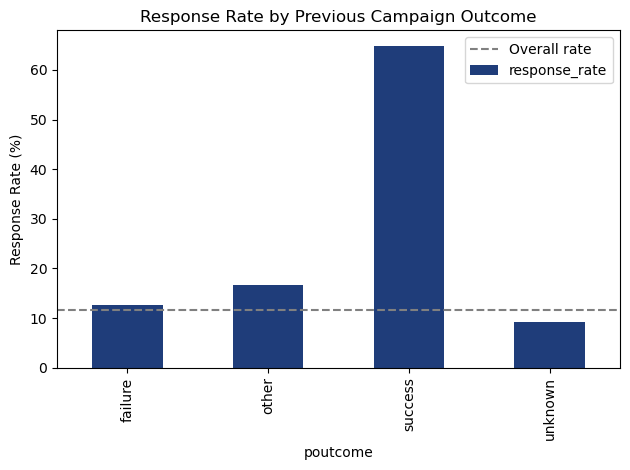

In [11]:
response_chart("poutcome", "Response Rate by Previous Campaign Outcome")

### 5.2 Age group

In [12]:
response_table("age_group")

,customers,subscribers,response_rate
age_group,,,
<=30,7030,1145,16.29
31-40,17687,1812,10.24
41-50,11239,1019,9.07
51-60,8067,811,10.05
60+,1188,502,42.26


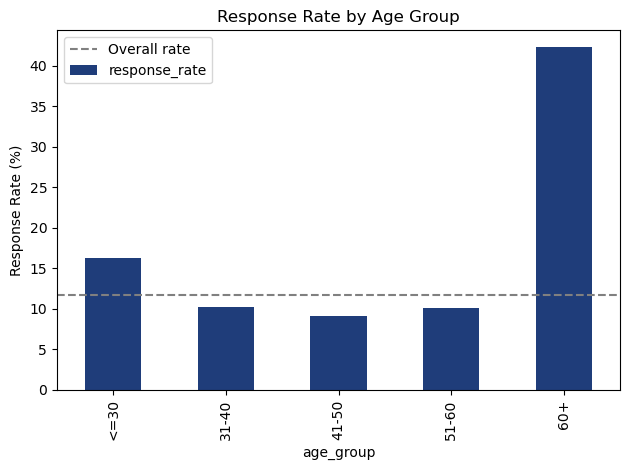

In [13]:
response_chart("age_group", "Response Rate by Age Group")

### 5.3 Job

In [14]:
response_table("job").sort_values("response_rate", ascending=False)

,customers,subscribers,response_rate
job,,,
student,938,269,28.68
retired,2264,516,22.79
unemployed,1303,202,15.50
management,9458,1301,13.76
admin.,5171,631,12.20
self-employed,1579,187,11.84
unknown,288,34,11.81
technician,7597,840,11.06
services,4154,369,8.88


### 5.4 Number of calls in this campaign

In [15]:
response_table("contact_band")

,customers,subscribers,response_rate
contact_band,,,
1 Contact,17544,2561,14.60
2-3 Contacts,18026,2019,11.20
4-5 Contacts,5286,456,8.63
6+ Contacts,4355,253,5.81


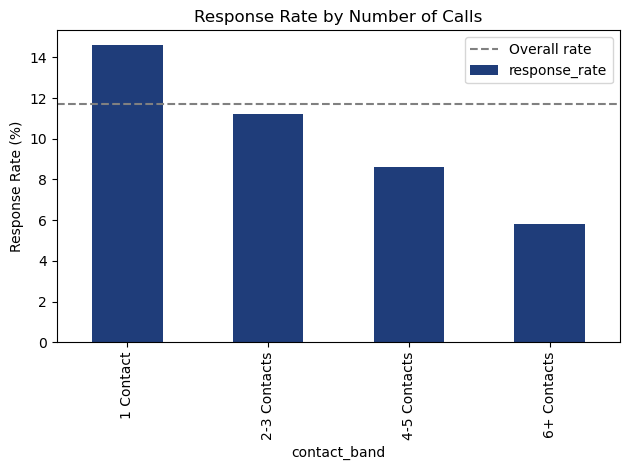

In [16]:
response_chart("contact_band", "Response Rate by Number of Calls")

### 5.5 Housing loan and personal loan

In [17]:
response_table("housing")

,customers,subscribers,response_rate
housing,,,
no,20081,3354,16.7
yes,25130,1935,7.7


In [18]:
response_table("loan")

,customers,subscribers,response_rate
loan,,,
no,37967,4805,12.66
yes,7244,484,6.68


## 6. Hypothesis Testing (Chi-square Test of Independence)
Both variables in each test are categorical, so the chi-square test of independence is used.

- **H0:** the variable and subscription are independent (no relationship).
- **H1:** they are related.
- If p-value < 0.05, reject H0.

In [19]:
def chi_square_test(column):
    table = pd.crosstab(bank[column], bank["subscribed"])
    chi2_stat, p_value, dof, expected = chi2_contingency(table)
    print("Variable:", column)
    print("Chi-square statistic:", round(chi2_stat, 2), "| degrees of freedom:", dof)
    print("p-value:", "< 0.001" if p_value < 0.001 else round(p_value, 4))
    if p_value < 0.05:
        print("Conclusion: Reject H0. This variable is related to subscription.")
    else:
        print("Conclusion: Fail to reject H0. No significant relationship found.")
    print()

In [20]:
chi_square_test("poutcome")   # Test 1: previous campaign outcome
chi_square_test("age_group")  # Test 2: age group

Variable: poutcome
Chi-square statistic: 4391.51 | degrees of freedom: 3
p-value: < 0.001
Conclusion: Reject H0. This variable is related to subscription.

Variable: age_group
Chi-square statistic: 1349.86 | degrees of freedom: 4
p-value: < 0.001
Conclusion: Reject H0. This variable is related to subscription.



## 7. Logistic Regression: Response Model
**Goal:** estimate each customer's probability of subscribing **before the bank calls them**.

The model only uses information the bank already has before a campaign starts:
- Numeric: `balance_000`, `previous`
- Categorical: `age_group`, `job`, `marital`, `education`, `housing`, `loan`, `contact`, `poutcome`

Not used:
- `duration`: known only after the call (data leakage).
- `campaign`: number of calls in this campaign, not known before the campaign starts.
- `day`, `month`: describe the call schedule, not the customer.
- `pdays`: uses -1 as a code for "never contacted"; `poutcome` already captures this.

In [21]:
number_columns = ["balance_000", "previous"]
category_columns = ["age_group", "job", "marital", "education", "housing", "loan", "contact", "poutcome"]

# One-hot encoding: each category becomes a 0/1 column.
# drop_first=True drops one category per column; it becomes the "base" group.
X = pd.get_dummies(bank[number_columns + category_columns], columns=category_columns, drop_first=True, dtype=int)
y = bank["subscribed"]

print("Number of model inputs after encoding:", X.shape[1])

Number of model inputs after encoding: 29


### Train-test split
80% of customers train the model; 20% are kept aside to test it on customers it has never seen.
`stratify=y` keeps the same response rate in both parts.

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Train customers:", len(X_train), "| response rate:", round(y_train.mean() * 100, 2), "%")
print("Test customers:", len(X_test), "| response rate:", round(y_test.mean() * 100, 2), "%")

Train customers: 36168 | response rate: 11.7 %
Test customers: 9043 | response rate: 11.7 %


### Train the model

In [23]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


### What the model learned (odds ratios)
**Odds ratio = e^(coefficient).**
- Above 1: the group is **more** likely to subscribe than the base group.
- Below 1: **less** likely.

Base groups (dropped by `drop_first`): age `<=30`, job `admin.`, marital `divorced`, education `primary`, housing `no`, loan `no`, contact `cellular`, poutcome `failure`.

In [24]:
odds_table = pd.DataFrame({
    "coefficient": model.coef_[0],
    "odds_ratio": np.exp(model.coef_[0])
}, index=X.columns).round(2)

odds_table.sort_values("odds_ratio", ascending=False)

,coefficient,odds_ratio
poutcome_success,2.23,9.33
age_group_60+,0.86,2.35
education_tertiary,0.30,1.34
job_student,0.25,1.28
poutcome_other,0.25,1.28
education_unknown,0.15,1.16
education_secondary,0.14,1.15
job_unemployed,0.08,1.08
balance_000,0.02,1.02
marital_single,0.02,1.02


### Evaluate on the test set: ROC-AUC
ROC-AUC measures how well the model **ranks** subscribers above non-subscribers (0.5 = random, 1 = perfect).

Accuracy is not used as the main metric: predicting "no" for everyone would already be about 88% accurate but would find zero subscribers.

In [25]:
test_probability = model.predict_proba(X_test)[:, 1]
print("ROC-AUC (test):", f"{roc_auc_score(y_test, test_probability):.3f}")

ROC-AUC (test): 0.750


## 8. Score All Customers and Create Targeting Segments
Every customer gets a response probability. Customers are then split into four equal groups (quartiles) by probability:
**Low, Medium, High, Very High.**

A `data_split` column marks whether each customer was used for training or testing, so SQL, Excel and Power BI can check results on test customers only.

In [26]:
bank["predicted_response_probability"] = model.predict_proba(X)[:, 1].round(4)

bank["targeting_segment"] = pd.qcut(
    bank["predicted_response_probability"],
    q=4,
    labels=["Low", "Medium", "High", "Very High"]
)

bank["data_split"] = "train"
bank.loc[X_test.index, "data_split"] = "test"

bank["data_split"].value_counts()

data_split
train    36168
test      9043
Name: count, dtype: int64

## 9. Lift Analysis (Test Customers Only)
Checked only on the 20% test customers the model never saw.

- **Lift** = segment response rate / overall response rate. Above 1 = better than average.
- **Share of subscribers** = % of all test subscribers that fall in the segment.
- **Calls per subscriber** = how many calls the bank makes, on average, to get one "yes".

In [27]:
test_customers = bank[bank["data_split"] == "test"]
test_rate = test_customers["subscribed"].mean() * 100

lift_table = test_customers.groupby("targeting_segment", observed=False).agg(
    customers=("subscribed", "count"),
    subscribers=("subscribed", "sum")
)
lift_table["response_rate"] = lift_table["subscribers"] / lift_table["customers"] * 100
lift_table["lift"] = lift_table["response_rate"] / test_rate
lift_table["share_of_subscribers"] = lift_table["subscribers"] / lift_table["subscribers"].sum() * 100
lift_table["calls_per_subscriber"] = lift_table["customers"] / lift_table["subscribers"]

# Best segment first
lift_table = lift_table.sort_index(ascending=False)

print("Overall response rate (test customers):", round(test_rate, 2), "%")
lift_table.round(2)

Overall response rate (test customers): 11.7 %


,customers,subscribers,response_rate,lift,share_of_subscribers,calls_per_subscriber
targeting_segment,,,,,,
Very High,2330,597,25.62,2.19,56.43,3.90
High,2216,238,10.74,0.92,22.50,9.31
Medium,2201,140,6.36,0.54,13.23,15.72
Low,2296,83,3.61,0.31,7.84,27.66


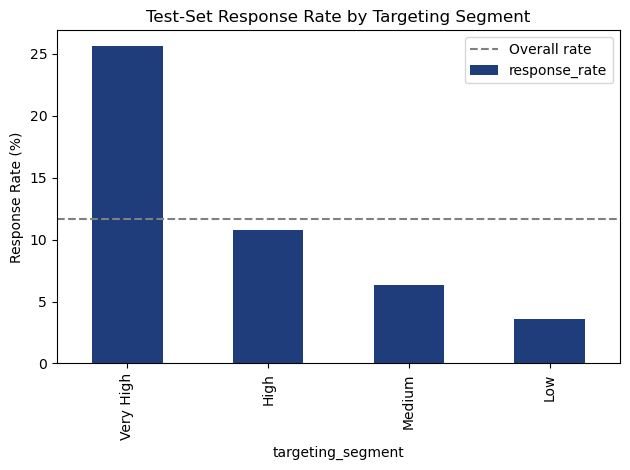

In [28]:
lift_table["response_rate"].plot(kind="bar", color="#1F3D7A", title="Test-Set Response Rate by Targeting Segment")
plt.axhline(test_rate, color="grey", linestyle="--", label="Overall rate")
plt.ylabel("Response Rate (%)")
plt.legend()
plt.tight_layout()
plt.show()

### Call plan: what happens if the bank calls segments in order?
Cumulative view: call Very High first, then add High, and so on.

In [29]:
call_plan = lift_table[["customers", "subscribers"]].cumsum()
call_plan["share_of_customers_called"] = call_plan["customers"] / len(test_customers) * 100
call_plan["share_of_subscribers_reached"] = call_plan["subscribers"] / test_customers["subscribed"].sum() * 100
call_plan["response_rate"] = call_plan["subscribers"] / call_plan["customers"] * 100
call_plan.index = ["Very High only", "+ High", "+ Medium", "+ Low (everyone)"]
call_plan.round(2)

,customers,subscribers,share_of_customers_called,share_of_subscribers_reached,response_rate
Very High only,2330,597,25.77,56.43,25.62
+ High,4546,835,50.27,78.92,18.37
+ Medium,6747,975,74.61,92.16,14.45
+ Low (everyone),9043,1058,100.00,100.00,11.70


### Confusion matrix for the rule "call only the Very High segment"
- Predicted "yes" = customer is in the Very High segment.
- **Precision** = response rate of the customers we call.
- **Recall** = share of all subscribers we reach.

In [30]:
call_decision = (test_customers["targeting_segment"] == "Very High").astype(int)
tn, fp, fn, tp = confusion_matrix(test_customers["subscribed"], call_decision).ravel()

print("Called and subscribed (TP):", tp)
print("Called but did not subscribe (FP):", fp)
print("Not called but would have subscribed (FN):", fn)
print("Not called and would not subscribe (TN):", tn)
print("Precision:", round(tp / (tp + fp) * 100, 2), "%")
print("Recall:", round(tp / (tp + fn) * 100, 2), "%")

Called and subscribed (TP): 597
Called but did not subscribe (FP): 1733
Not called but would have subscribed (FN): 461
Not called and would not subscribe (TN): 6252
Precision: 25.62 %
Recall: 56.43 %


## 10. Export Files for SQL, Excel and Power BI
`bank_marketing_master.csv` = all original columns plus `customer_id`, `subscribed`, `age_group`, `contact_band`, `balance_000`, `predicted_response_probability`, `targeting_segment`, `data_split`.

In [31]:
bank.to_csv("bank_marketing_master.csv", index=False)
lift_table.round(2).to_csv("bank_marketing_lift_table.csv")

print("Saved: bank_marketing_master.csv", bank.shape)
print("Saved: bank_marketing_lift_table.csv")

Saved: bank_marketing_master.csv (45211, 25)
Saved: bank_marketing_lift_table.csv


## 11. Key Findings
From this run (45,211 customers; model results on 9,043 unseen test customers):

**Campaign overview**
- 5,289 customers subscribed, an overall response rate of **11.70%**. Calling at random needs about **8.5 calls per subscriber**.

**Who responds (exploratory analysis)**
- **Previous campaign:** customers who said yes last time responded at **64.73%**, against 9.16% for customers never contacted before.
- **Age:** U-shaped pattern. Customers aged **60+ responded at 42.26%** and those aged ≤30 at 16.29%; the 41–50 group was lowest at 9.07%.
- **Job:** students (28.68%) and retired customers (22.79%) responded the most; blue-collar customers the least (7.27%).
- **Loans:** no housing loan 16.70% vs 7.70% with one; no personal loan 12.66% vs 6.68%.
- **Number of calls:** response falls from 14.60% for customers called once to 5.81% for customers called 6+ times.
- **Chi-square tests:** previous campaign outcome and age group are both significantly related to subscription (p < 0.001).

**Model (Logistic Regression, pre-call information only)**
- **ROC-AUC 0.750** on test customers.
- Strongest drivers: previous campaign success (odds ratio **9.33** vs previous failure) and age 60+ (**2.35** vs age ≤30). Housing loan (0.59) and personal loan (0.65) lower the odds.
- Retired customers have a high raw response rate but an odds ratio close to 1 in the model: age and job overlap (74% of customers aged 60+ are retired), so once age is in the model, being retired adds little extra.

**Targeting (test customers)**
- **Very High** segment: response rate **25.62%**, lift **2.19**, holding **56.43%** of all subscribers while being about a quarter of customers.
- Calls per subscriber fall from **8.5** (random) to **3.9** (Very High segment only).
- Calling Very High + High (about half of customers) reaches **78.92%** of subscribers at an 18.37% response rate.

These are associations, not proof that one factor causes another.

## 12. Campaign Recommendation
1. **Call the Very High segment first.** It is the only segment that clearly beats the average (lift 2.19) and holds more than half of all subscribers.
2. **Call the High segment only if call-centre capacity remains** (lift 0.92, about average).
3. **Use cheaper channels (SMS, email) for Medium and Low** customers.
4. **Prioritise previous-campaign responders**, who responded at 64.73%.
5. **Cap repeat calls at 3 per customer.** Response is 14.6% on the first call, about 11.2% for the 2nd–3rd, and drops below the average from the 4th call onward.

## 13. Limitations
- The data is from 2008–2010; customer behaviour may be different today.
- The train-test split is random, not by time. A stricter check would train on earlier months and test on later months.
- The number-of-calls pattern may partly be reverse cause: customers who are hard to convince get called more often.
- The model ranks customers well but is not perfect: calling only the Very High segment still misses 43.57% of subscribers.
- The strategy should be tested on the next campaign, keeping a small random group of customers as a comparison.

### Interview summary
> I analysed 45,211 customers from a bank's term-deposit campaign. EDA and chi-square tests showed previous-campaign responders and customers aged 60+ respond far above the 11.7% average. I then built a Logistic Regression model using only pre-call information (ROC-AUC 0.750), split customers into four segments by predicted probability, and checked them on unseen test customers. The top segment responded at 25.6%, 2.19 times the average, and held 56% of all subscribers, cutting calls needed per subscriber from 8.5 to 3.9. I ran segment queries in SQL and built the summary in Excel and Power BI.